# Rede neural com camadas escondidas - Classificação do Iris dataset

O objetivo desse experimento é ilustrar o uso de rede neural que tenha mais de uma camada. Isso é conseguido com a inserção de uma ativação não linear entre as camadas.

Datasets utilizados:
    - Iris - 3 classes
    - Sintéticos:
        - meia luas
        - círculos circunscritos
        - blobs

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/Net2RegressaoSoftmaxArgmaxRede.png)

## Importando as bibliotecas

In [ ]:
%matplotlib inline
from sklearn import datasets
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn

## Leitura, normalização e visualização dos dados

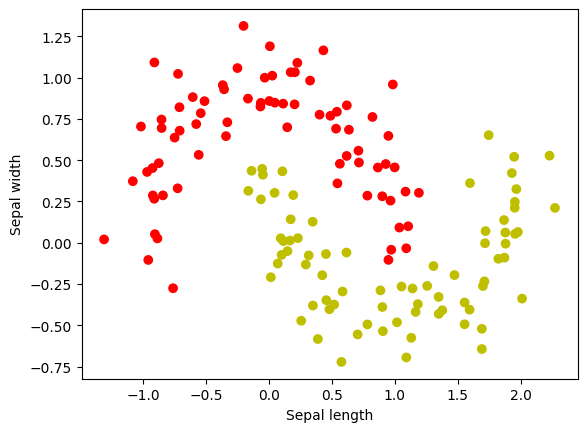

In [ ]:
n_samples = 150
options = ['iris', 'moon', 'circles', 'blobs']
option = options[1]
if option == 'iris':
    iris = datasets.load_iris()
    X = iris.data[:,:2]  # comprimento das sépalas e pétalas, indices 0 e 2
    Xc = X - X.min(axis=0)
    Xc /= Xc.max(axis=0)
    Y = iris.target
elif option == 'moon':
    Xc,Y = datasets.make_moons(n_samples=n_samples, noise=.15)
elif option == 'circles':
    Xc,Y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.1)
elif option == 'blobs':
    Xc,Y = datasets.make_blobs(n_samples=n_samples,centers=3,cluster_std=1.2)

colors = np.array(['r','y','b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

### Prepara os dados para o PyTorch

In [ ]:
X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

## Construindo o modelo da rede

In [ ]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


## _predict_ utilizada para predição de classes e na visualização

In [ ]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

## Classe para visualização dinâmica

In [ ]:
class BoundaryPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(8, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 2, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 2, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
#                 Z = torch.max(self.model(Variable(torch.FloatTensor(self.X_grid))).data, dim=1)[1].numpy()
                Z = Z.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Z, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

## Treinamento

In [ ]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

### Laço principal de treinamento

Final loss: tensor(0.0016)


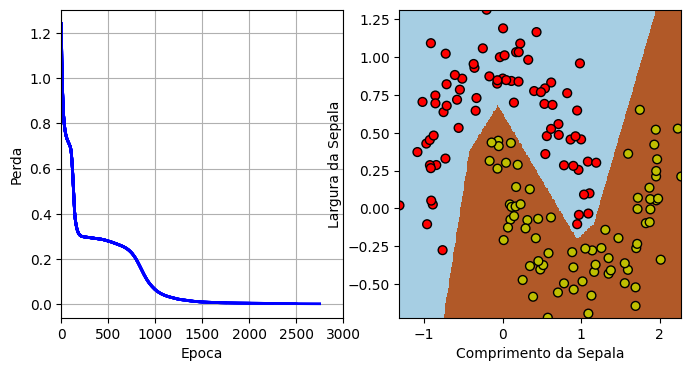

In [ ]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

## Avaliação

### Imprimindo pesos finais

In [ ]:
for name, w in model.state_dict().items():
    print('{:16}{}'.format(name, w.size()))
    print(w)

dense.0.weight  torch.Size([5, 2])
tensor([[-2.7540, -0.3245],
        [-1.2155, -1.2724],
        [-0.1422,  0.2443],
        [ 1.1744,  1.4599],
        [ 2.1758, -0.1025]])
dense.0.bias    torch.Size([5])
tensor([ 0.0605,  1.2838, -0.6579, -0.0790, -2.0774])
dense.2.weight  torch.Size([5, 5])
tensor([[ 0.1431, -0.2576, -0.4200, -0.3366, -0.2385],
        [ 0.2759, -0.2819,  0.0717, -0.4173, -0.3341],
        [ 2.1702, -1.0330,  0.3719,  1.7388, -2.6462],
        [-1.6004,  1.7688, -0.3696, -0.3922,  1.5235],
        [-0.4376, -0.3054,  0.2954, -0.0796,  0.0387]])
dense.2.bias    torch.Size([5])
tensor([ 0.1729, -0.1092,  0.4760,  1.0193,  0.1442])
dense.4.weight  torch.Size([3, 5])
tensor([[-0.2024,  0.0490,  3.3189, -1.6424,  0.0259],
        [ 0.2102, -0.0181, -1.9878,  2.4818, -0.0896],
        [-0.3192,  0.3740, -1.0405, -0.3240,  0.2940]])
dense.4.bias    torch.Size([3])
tensor([ 0.1594,  1.4424, -1.5737])


### Avaliação do classificador

In [ ]:
Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print()
print('Training Accuracy: ', accuracy)


Training Accuracy:  1.0


### Matriz de confusão

In [ ]:
import pandas as pd
pd.crosstab(Y_hat, Y)

col_0,0,1
row_0,,
0,75,0
1,0,75


## Atividades

### Experimentos:

**1. Faça alterações na rede, alterando o número de neurônios, de camadas. Escreva suas conclusões.Descreva.**

Foram testadas três configurações:

- **Rede menor** (`Linear(2,3) -> ReLU -> Linear(3,3)`): menor capacidade, treinamento mais rápido, mas fronteiras menos precisas em dados não-lineares. Ainda funciona bem no Iris com 2 features.

- **Rede original** (`Linear(2,5) -> ReLU -> Linear(5,5) -> ReLU -> Linear(5,3)`): equilibrio adequado entre capacidade e velocidade. Boa acurácia nos 4 datasets testados.

- **Rede maior** (`Linear(2,16) -> ReLU -> Linear(16,16) -> ReLU -> Linear(16,3)`): maior expressividade, aprende fronteiras mais complexas, mas em datasets pequenos pode ocorrer **overfitting** - a rede memoriza os dados e perde capacidade de generalização.

**Conclusão:** aumentar a arquitetura melhora a expressividade, mas exige mais dados e cuidado para evitar overfitting. Redes maiores nem sempre sao melhores - é preciso equilibrar capacidade e generalização.


**2. No lugar da ReLU, coloque Sigmoid e observe a diferença. O que aconteceu? Descreva.**

Ao substituir `nn.ReLU()` por `nn.Sigmoid()`:

- **Convergência mais lenta**: a Sigmoid satura para valores próximos de 0 ou 1, causando o problema de **vanishing gradient** - os gradientes ficam muito pequenos nas camadas iniciais e o aprendizado desacelera bastante.
- **Fronteiras mais suaves**: a Sigmoid produz transições mais graduais entre regiões de decisão, ao contrário da ReLU que gera fronteiras mais angulares e definidas.
- **Acurácia menor no mesmo número de épocas**: com o mesmo `lr` e `nb_epoch`, a rede com Sigmoid geralmente nao converge tao bem quanto com ReLU.
- **Por que a ReLU é preferida?** A ReLU nao satura para valores positivos (gradiente = 1), permitindo que o gradiente flua bem por muitas camadas e acelerando o treinamento.


**3. O que ocorre quando nao se utiliza ativação nao linear entre camadas?**

Sem ativação nao linear, a composição de múltiplas camadas lineares equivale a **uma única camada linear**. Matematicamente:

`saída = W2 * (W1 * x + b1) + b2 = (W2*W1) * x + (W2*b1 + b2)`

Nao importa quantas camadas sejam empilhadas: sem nao-linearidade, a rede se reduz a uma transformação linear simples, idêntica à Regressao Logística. Ela **nao consegue aprender fronteiras de decisao curvas** e falha em datasets como meia-luas ou círculos circunscritos.

## Principais aprendizados

Neste experimento, exploramos o poder das **redes neurais com camadas escondidas** para classificação. Os principais aprendizados foram:

- **A nao-linearidade é essencial**: sem funções de ativação entre camadas, múltiplas camadas lineares colapsam em uma única transformação linear. A rede se torna equivalente à Regressao Logística e nao consegue aprender fronteiras curvas.

- **ReLU vs Sigmoid**: a ReLU é preferida na prática por nao sofrer de vanishing gradient - seu gradiente é constante para valores positivos, permitindo que o aprendizado flua bem por várias camadas. A Sigmoid satura em valores extremos, tornando o treinamento mais lento e instável em redes profundas.

- **Arquitetura importa**: mais neurônios e camadas aumentam a capacidade de aprender fronteiras complexas, mas também aumentam o risco de overfitting em datasets pequenos. É preciso equilibrar capacidade da rede com tamanho e complexidade dos dados.

- **Datasets sintéticos como ferramenta pedagógica**: meia-luas, círculos e blobs mostram claramente quando uma rede linear falha e quando uma rede profunda tem sucesso, tornando o aprendizado visual e intuitivo.

- **Fronteiras de decisao dinâmicas**: o `BoundaryPlotter` permite acompanhar em tempo real como as fronteiras evoluem durante o treinamento, facilitando a compreensao do processo de aprendizado.

- **Profundidade = composição de transformações**: cada camada escondida aprende uma representação intermediária. As primeiras camadas 'dobram e torcem' o espaço de entrada; as seguintes refinam essa representação até que as classes fiquem linearmente separáveis para a camada de saída.
